In [1]:
import pandas as pd
import numpy as np
#need to pip install pyxlsb
#need to pip install openpyxl pour le .xlsx
import matplotlib.pyplot as plt


Dans toute cette étude, nous nous intéressons aux résultats obtenus par le "bloc de gauche" aux élections municipales de 2014 et 2020. 
Nous considérons ici que ce bloc correspond à au groupe Europe Ecologie-Les Verts (LVEC), au groupe Ecologiste (LECO), au groupe Union de la Gauche (LUG), au groupe Divers Gauche (LDVG), au groupe (LSOC) et au groupe Liste du Parti de Gauche (LPG)

In [2]:
#on définit donc le array suivant

BLOC_GAUCHE_ECOLO = [
    'LVEC', 'LVECE',# Europe Ecologie-Les Verts
    'LECO',  # Ecologiste
    'LUG',   # Union de la Gauche
    'LDVG',   # Divers Gauche
    'LSOC',	 #Parti socialiste
    'LPG'	#Liste du Parti de Gauche
]


## Création de la base de donnée relatives aux résultats de l'élection communale de 2020
Pour des fins de comparabilité, nous avons choisit de concentrer notre analyse sur les communes de France métropolitaine (donc sans les données des DROMs, COMs, Terres australes et de Nouvelle Calédonie). Pour ce faire, nous avons récupéré la base de donnée des résultats à laquelle nous avons rajouté la nuance politique da la liste élue par *merging* avec la base de donnée des candidats. Cette donnée n'est disponible que pour les communes de plus de 3 500 habitants 

In [3]:
#Nous faisons le choix d'enlever les DROM, les COM, les Terres australes et la Nouvelle-Calédonie : code de département None ou supérieurs à 900
#le département de corse du sud sera noté 201 au lieu de 2A et haute corse 202 au lieu de 2B
resultats_2020 = pd.read_excel(
    '/home/onyxia/work/Python-project/Data/data_pour_nos_codes/data_elec/2020-06-29-resultats-t2-communes-de-1000-hab-et-plus.xlsx',
    header=0,
    dtype={'Code de la commune': str, 'Code du département': str}
)


resultats_2020['Code du département'] = resultats_2020['Code du département'].replace({'2A': '201', '2B': '202'})
resultats_2020['Code du département'] = pd.to_numeric(resultats_2020['Code du département'], errors='coerce')
resultats_2020 = resultats_2020[resultats_2020['Code du département'] < 900]


resultats_2020['Code commune'] = (
    resultats_2020['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2020['Code de la commune'].astype(str).str.zfill(3)
)
resultats_2020.head(5)

,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Code commune
0,1.0,Ain,034,Belley,5757,2877,49.97,2880,50.03,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01034
1,1.0,Ain,160,Ferney-Voltaire,3798,2280,60.03,1518,39.97,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01160
2,1.0,Ain,194,Jassans-Riottier,4357,2689,61.72,1668,38.28,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01194
3,1.0,Ain,249,Miribel,6847,4064,59.35,2783,40.65,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01249
4,1.0,Ain,354,Saint-Genis-Pouilly,5015,3108,61.97,1907,38.03,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01354


In [4]:
# Pour chaque commune, nous récupérons le vainqueur de l'élection qui à remporté par définition
# le plus de voix. A la différence d'une base de données où seuls les gagnants sont indiqués, cela
# nous permet de connaitre le pourcentage de voix exprimé en sa faveur

commune_cols = ['Code commune', 'Libellé de la commune']

candidate_fields = [
    'N.Pan.', 'Code Nuance', 'Sexe', 'Nom', 'Prénom', 'Liste',
    'Sièges / Elu', 'Sièges Secteur', 'Sièges CC', 'Voix', '% Voix/Ins', '% Voix/Exp'
]

# Identification des blocs candidats et traitement pour chaque commune
cols = list(resultats_2020.columns)
start = cols.index('N.Pan.') 
k = len(candidate_fields)
nblocks = (len(cols) - start) // k

dfs = []
for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2020[commune_cols + blk_cols].copy()
    cand_df.columns = commune_cols + candidate_fields
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs.append(cand_df)

long_df_2020 = pd.concat(dfs, ignore_index=True)

long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90


In [5]:
idx = long_df_2020.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df_2020["winner"] = "no"
long_df_2020.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)

,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01,no
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70,no
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90,no


In [6]:

# Sélection du vainqueur pour chaque commune, avec son résultat en pourcentage
long_df_2020['% Voix/Exp'] = pd.to_numeric(long_df_2020['% Voix/Exp'], errors='coerce')
winners_2020 = long_df_2020.loc[long_df_2020.groupby('Code commune')['% Voix/Exp'].idxmax()].copy()

winners_2020['D_elec_2020'] = np.where(
    winners_2020["Code Nuance"].isna(),
    np.nan,
    winners_2020["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de communes traitées : {len(winners_2020)}")
display(winners_2020.head())

Nombre de communes traitées : 1340


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2020
1340,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes,0.0
1341,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes,0.0
3573,01194,Jassans-Riottier,4.0,LDVD,M,REVERCHON,Jean-Pierre,JASSANS LA FORCE D'AGIR ENSEMBLE,23.0,0.0,5.0,856.0,19.65,52.16,yes,0.0
3,01249,Miribel,1.0,LDVD,M,GAITET,Jean-Pierre,"Miribel pour tous, Miribel à tous",23.0,0.0,11.0,1391.0,20.32,50.73,yes,0.0
1344,01354,Saint-Genis-Pouilly,2.0,LDVG,M,BERTRAND,Hubert,"SAINT-GENIS-POUILLY, C'EST VOUS",25.0,0.0,5.0,867.0,17.29,46.12,yes,1.0


## Création de la base de donnée relatives aux résultats de l'élection communale de 2014
Comme pour la base précédente, une étape de filtrage est d'abord nécessaire sur la base importée, une adaptation de la base au traitement, on restreint les variables présentes à celles qui nous intéresse et on détermine ensuite l'élu pour chaque commune avec sa nuance politique.

In [7]:
resultats_2014 = pd.read_excel('/home/onyxia/work/Python-project/Data/data_pour_nos_codes/data_elec/muni-2014-resultats-com-1000-et-plus-t2.xlsx', header=0)
resultats_2014.head(5)

,Date de l'export,Code du département,Type de scrutin,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,...,Unnamed: 623,Unnamed: 624,Unnamed: 625,Unnamed: 626,Unnamed: 627,Unnamed: 628,Unnamed: 629,Unnamed: 630,Unnamed: 631,Unnamed: 632
0,2014-03-31 09:33:41,1,LI2,AIN,4,Ambérieu-en-Bugey,8198,3619,44.14,4579,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-03-31 09:33:41,1,LI2,AIN,7,Ambronay,1770,434,24.52,1336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-03-31 09:33:41,1,LI2,AIN,34,Belley,5680,1557,27.41,4123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-03-31 09:33:41,1,LI2,AIN,160,Ferney-Voltaire,4070,1882,46.24,2188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-03-31 09:33:41,1,LI2,AIN,185,Hauteville-Lompnes,2252,803,35.66,1449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Remplacement des codes Corse
resultats_2014['Code du département'] = resultats_2014['Code du département'].replace({'2A': '201', '2B': '202'})

# Convertir en Int64 et forcer NaN si non convertible
resultats_2014['Code du département'] = pd.to_numeric(resultats_2014['Code du département'], errors='coerce').astype('Int64')

# Supprimer les DROM/COM/TAAF/Nouvelle-Calédonie (codes >900 ou NaN)
resultats_2014 = resultats_2014.dropna(subset=['Code du département'])
resultats_2014 = resultats_2014[resultats_2014['Code du département'] <= 900]

# Créer un code commune unique : 2 chiffres département + 3 chiffres commune
resultats_2014['Code commune'] = (
    resultats_2014['Code du département'].astype(str).str.zfill(2) +
    resultats_2014['Code de la commune'].astype(str).str.zfill(3)
    )


In [9]:
df = resultats_2014.copy()

commune_cols = ['Code commune', 'Libellé de la commune']
candidate_fields = ['Code Nuance','Sexe','Nom','Prénom','Liste',
                    'Sièges / Elu','Sièges Secteur','Sièges CC','Voix','% Voix/Ins','% Voix/Exp']
k = len(candidate_fields)

# Position du premier bloc
cols = list(df.columns)
start = cols.index('Code Nuance')
nblocks = (len(cols) - start) // k

# Liste pour stocker les futurs lignes par bloc
dfs = []

for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k:
        continue
    cand_df = df[commune_cols + blk_cols].copy()
    cand_df = cand_df.rename(columns=dict(zip(blk_cols, candidate_fields)))
    cand_df = cand_df[cand_df['Nom'].notna() & (cand_df['Nom'].str.strip() != '')]
    dfs.append(cand_df)

long_df = pd.concat(dfs, ignore_index=True)


In [10]:
idx = long_df.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df["winner"] = "no"
long_df.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes
1,01004,Ambérieu-en-Bugey,LDVG,F,PIDOUX,Catherine,VIVONS NOTRE VILLE,3,0.0,0.0,741.0,9.04,16.96,no
2,01004,Ambérieu-en-Bugey,LDVG,F,EXPOSITO,Josiane,AMBERIEU AMBITION,3,0.0,1.0,949.0,11.58,21.73,no
3,01007,Ambronay,LDVD,M,FOURNIER,Gabriel,AMBRONAY Demain,1,0.0,0.0,153.0,8.64,11.73,no
4,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes


In [11]:
winners_2014 = long_df_sorted.loc[long_df_sorted['winner']=='yes'].reset_index(drop=True)

winners_2014['D_elec_2014'] = np.where(
    winners_2014["Code Nuance"].isna(),
    np.nan,  # keep NaN
    winners_2014["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de lignes : {len(winners_2014)}")
display(winners_2014.head(5))

print(winners_2014['Code Nuance'].unique())

Nombre de lignes : 1675


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2014
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes,0.0
1,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes,1.0
2,01034,Belley,LDVD,M,JIMENEZ,Christian,BELLEY NOUVEL HORIZON 2014,22,0.0,14.0,2029.0,35.72,51.17,yes,0.0
3,01160,Ferney-Voltaire,LDVD,M,RAPHOZ,Daniel,FERNEY-VOLTAIRE VALEURS COMMUNES,22,0.0,4.0,1075.0,26.41,50.45,yes,0.0
4,01185,Hauteville-Lompnes,LUDI,M,ARGENTI,Bernard,OSONS L'AVENIR,22,0.0,6.0,815.0,36.19,61.28,yes,0.0


['LDVD' 'LDVG' 'LUDI' 'LDIV' 'LVEC' 'LFN' 'LUD' 'LSOC' 'LUG' 'LUMP' 'LPG'
 'LFG' 'LCOM' 'LUC' 'LMDM' 'LEXD']


In [12]:
winners_2014.to_csv('elec_2014.csv', index=False)
winners_2020.to_csv('elec_2020.csv', index=False)

## Statistiques descriptives sur les bases de données 
Pour rappel, nous avons importé les résultats des élections communales de 2020 pour les communes de plus de 3500 habitants, les résultats de 2014. Commençons à comparer ces 2 bases.

In [ ]:
counts_2014 = winners_2014['Code Nuance'].value_counts(normalize=True) * 100 
counts_2014 = counts_2014.sort_values(ascending=True)


Code Nuance
LPG      0.059701
LEXD     0.119403
LVEC     0.179104
LUC      0.358209
LMDM     0.417910
LCOM     0.477612
LFN      0.597015
LFG      0.656716
LUDI     1.910448
LUMP     5.194030
LSOC     5.970149
LUG      9.552239
LUD      9.791045
LDIV    14.388060
LDVG    17.253731
LDVD    33.074627
Name: proportion, dtype: float64

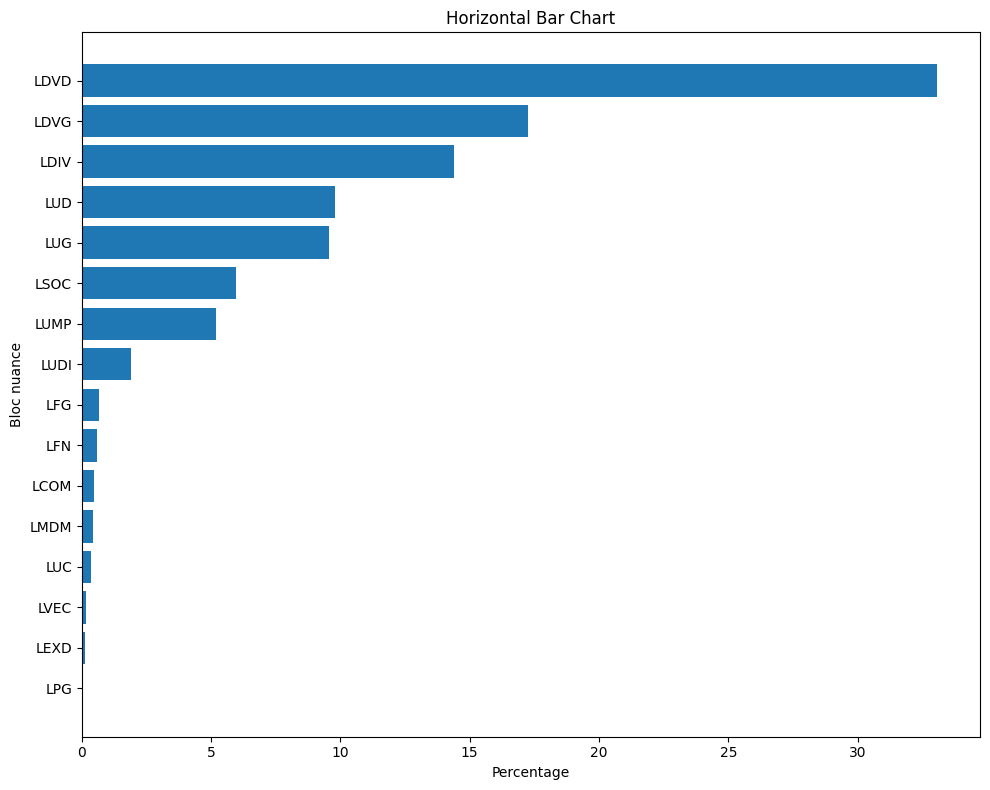

In [90]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(counts_2014.index, counts_2014.values)

ax.set_xlabel("Percentage")
ax.set_ylabel("Bloc nuance")
ax.set_title("Horizontal Bar Chart")

plt.tight_layout()
plt.show()


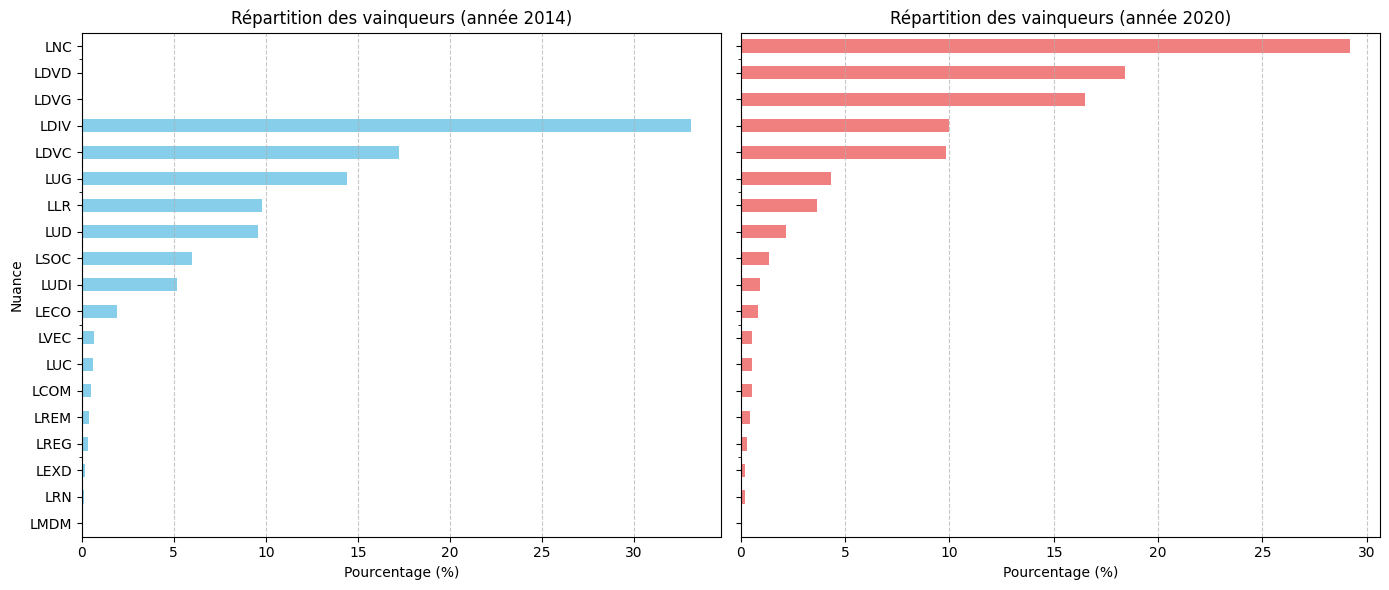

In [ ]:
counts_2020 = winners_2020['Code Nuance'].value_counts(normalize=True) * 100  # en pourcentage
counts_2020 = counts_2020.sort_values(ascending=True)

counts_2014 = winners_2014['Code Nuance'].value_counts(normalize=True) * 100  # en pourcentage
counts_2014 = counts_2014.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

counts_2014.plot(kind='barh', color='skyblue', ax=axes[0])
axes[0].set_xlabel('Pourcentage (%)')
axes[0].set_ylabel('Nuance')
axes[0].set_title('Répartition des vainqueurs (année 2014)')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

counts_2020.plot(kind='barh', color='lightcoral', ax=axes[1])
axes[1].set_xlabel('Pourcentage (%)')
axes[1].set_title('Répartition des vainqueurs (année 2020)')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()